# Retail Analytics Pipeline

---
### Tabla de Contenidos
- [Introducción y Documentación](./README.md)
- [Desarrollo](#development)
  - [1. Fundamentos de Big Data](#lesson1)
  - [2. Apache Spark — Introducción y Configuración](#lesson2)
  - [3. Elementos Básicos de Spark (RDD, Transformaciones y Acciones)](#lesson3)
  - [4. Procesamiento de Datos Estructurados (Spark SQL y DataFrames)](#lesson4)
  - [5. Machine Learning Escalable (Spark MLlib)](#lesson5)
- [Reporte Técnico](./technical_report.md)
---

## [Introducción y Documentación](./README.md)

## Desarrollo <a id="development"></a>

In [ ]:
# Importaciones generales
import os
import re
import subprocess
import zipfile

# Configuración de Hadoop para Windows (necesario para escritura Parquet)
HADOOP_HOME = os.path.join(os.getcwd(), "hadoop")
os.environ["HADOOP_HOME"] = HADOOP_HOME
os.environ["PATH"] = (
    os.path.join(HADOOP_HOME, "bin") + os.pathsep + os.environ.get("PATH", "")
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

### 1. Fundamentos de Big Data <a id="lesson1"></a>

Esta primera sección es de carácter conceptual. Su objetivo es reconocer el ecosistema
de Big Data y sus componentes básicos, aplicados al contexto de RetailMax.

#### 1.1 Las 5V de Big Data

Las **5V** son las dimensiones que caracterizan a un problema de Big Data:

| Dimensión | Descripción | Aplicación en RetailMax |
|---|---|---|
| **Volumen** | Cantidad masiva de datos generados. | Millones de transacciones diarias, historiales de navegación y reseñas acumuladas en la plataforma e-commerce. |
| **Velocidad** | Rapidez con que se generan y deben procesarse los datos. | Eventos de compra y navegación en tiempo real que requieren respuestas inmediatas (recomendaciones, detección de fraude). |
| **Variedad** | Diversidad de formatos y fuentes de datos. | Datos estructurados (transacciones, pagos), semi-estructurados (logs de navegación) y no estructurados (reseñas en texto libre). |
| **Veracidad** | Confiabilidad y calidad de los datos. | Posibles inconsistencias entre sistemas (duplicados, reseñas falsas, datos faltantes en registros de envío). |
| **Valor** | Capacidad de extraer información accionable. | Convertir los datos en insights de marketing: segmentar clientes, predecir satisfacción y optimizar inventario. |

#### 1.2 Fuentes de datos de RetailMax

En el escenario planteado, RetailMax dispone de tres grandes fuentes de datos:

1. **Transacciones de compra**: Registros estructurados con información de pedidos,
   productos, precios, pagos y envíos. Son la columna vertebral del análisis de negocio.

2. **Reseñas y calificaciones**: Datos semi-estructurados o no estructurados que
   contienen puntuaciones numéricas y comentarios en texto libre. Permiten medir la
   satisfacción del cliente.

3. **Comportamiento de navegación**: Logs de eventos (clics, búsquedas, tiempo en
   página) que capturan la actividad del usuario en la plataforma. Son datos de alta
   velocidad generados en streaming.

Para este proyecto emplearemos el **Brazilian E-Commerce Public Dataset by Olist**
como proxy de los datos de RetailMax, ya que contiene pedidos, ítems, clientes,
vendedores, pagos y reseñas de un marketplace real.

#### 1.3 Arquitectura propuesta

El siguiente diagrama describe el flujo de procesamiento que implementaremos
a lo largo de las lecciones:

```
┌────────────────────────────────────────────────────────────────────┐
│                   PIPELINE — RETAIL ANALYTICS                      │
├────────────────────────────────────────────────────────────────────┤
│                                                                    │
│  ┌────────────┐     ┌────────────────┐     ┌──────────────────┐    │
│  │  INGESTA   │     │ PROCESAMIENTO  │     │    ANÁLISIS      │    │
│  │            │     │                │     │                  │    │
│  │ CSVs Olist │────▶│ Spark (local)  │────▶│ Spark SQL       │    │
│  │ (Kaggle)   │     │ RDDs           │     │ DataFrames       │    │
│  └────────────┘     │ Transformac.   │     │ Métricas negocio │    │
│                     └───────┬────────┘     └────────┬─────────┘    │
│                             │                       │              │
│                             ▼                       ▼              │
│                     ┌────────────────┐     ┌──────────────────┐    │
│                     │ PERSISTENCIA   │     │  ML ESCALABLE    │    │
│                     │                │     │                  │    │
│                     │ Parquet        │────▶│ Spark MLlib      │    │
│                     │ (Optimizado)   │     │ - Reg. Logística │    │
│                     │                │     │ - K-Means        │    │
│                     └────────────────┘     └──────────────────┘    │
│                                                    │               │
│                                                    ▼               │
│                                            ┌──────────────┐        │
│                                            │   INSIGHTS   │        │
│                                            │  Marketing   │        │
│                                            └──────────────┘        │
└────────────────────────────────────────────────────────────────────┘
```

**Componentes clave:**
- **Ingesta**: Descarga del dataset desde Kaggle en formato CSV.
- **Procesamiento**: Spark en modo local, usando RDDs para transformaciones a bajo nivel.
- **Análisis**: DataFrames y Spark SQL para consultas de negocio optimizadas.
- **Persistencia**: Guardado en formato Parquet para lecturas eficientes.
- **ML Escalable**: Pipeline MLlib con modelos supervisado y no supervisado.

---
### 2. Apache Spark — Introducción y Configuración <a id="lesson2"></a>

En esta sección configuramos Spark en modo local y realizamos la carga
inicial de datos para validar la conectividad con el dataset.

#### 2.1 Descarga del dataset

In [ ]:
# Descarga del dataset Brazilian E-Commerce de Olist desde Kaggle
DATA_DIR = "data"
ZIP_FILE = os.path.join(DATA_DIR, "brazilian-ecommerce.zip")

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(ZIP_FILE):
    print("Descargando dataset desde Kaggle...")
    subprocess.run(
        [
            "curl.exe",
            "-L",
            "-o",
            ZIP_FILE,
            "https://www.kaggle.com/api/v1/datasets/download/olistbr/brazilian-ecommerce",
        ],
        check=True,
    )
    print("Descarga completada.")
else:
    print(f"El archivo {ZIP_FILE} ya existe. Se omite la descarga.")

El archivo data\brazilian-ecommerce.zip ya existe. Se omite la descarga.


In [ ]:
# Descompresión del dataset
EXTRACT_DIR = os.path.join(DATA_DIR, "brazilian-ecommerce")

if not os.path.exists(EXTRACT_DIR):
    print("Descomprimiendo dataset...")
    with zipfile.ZipFile(ZIP_FILE, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Descompresión completada.")
else:
    print(f"El directorio {EXTRACT_DIR} ya existe. Se omite la descompresión.")

# Listar archivos extraídos
csv_files = [f for f in os.listdir(EXTRACT_DIR) if f.endswith(".csv")]
print(f"\nArchivos CSV disponibles ({len(csv_files)}):")
for f in sorted(csv_files):
    print(f"  - {f}")

El directorio data\brazilian-ecommerce ya existe. Se omite la descompresión.

Archivos CSV disponibles (9):
  - olist_customers_dataset.csv
  - olist_geolocation_dataset.csv
  - olist_order_items_dataset.csv
  - olist_order_payments_dataset.csv
  - olist_order_reviews_dataset.csv
  - olist_orders_dataset.csv
  - olist_products_dataset.csv
  - olist_sellers_dataset.csv
  - product_category_name_translation.csv


#### 2.2 Configuración de SparkSession

In [ ]:
# Configuración de Spark en modo local
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder.master("local[*]")
    .appName("RetailAnalyticsPipeline")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

sc = spark.sparkContext
sc.setLogLevel("ERROR")

print(f"Spark Version: {spark.version}")
print(f"App Name: {spark.sparkContext.appName}")
print(f"Master: {spark.sparkContext.master}")

Spark Version: 4.1.1
App Name: RetailAnalyticsPipeline
Master: local[*]


#### 2.3 Carga inicial en RDDs

In [ ]:
# Carga de datos de pedidos en un RDD para exploración básica
orders_path = os.path.join(EXTRACT_DIR, "olist_orders_dataset.csv")
orders_rdd_raw = sc.textFile(orders_path)

# Exploración básica con acciones count y take
total_lines = orders_rdd_raw.count()
print(f"Total de líneas en orders (incluyendo encabezado): {total_lines}")
print(f"\nPrimeras 3 líneas:")
for line in orders_rdd_raw.take(3):
    print(f"  {line}")

Total de líneas en orders (incluyendo encabezado): 99442

Primeras 3 líneas:
  "order_id","customer_id","order_status","order_purchase_timestamp","order_approved_at","order_delivered_carrier_date","order_delivered_customer_date","order_estimated_delivery_date"
  e481f51cbdc54678b7cc49136f2d6af7,"9ef432eb6251297304e76186b10a928d",delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
  "53cdb2fc8bc7dce0b6741e2150273451",b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


In [ ]:
# Carga de datos de productos en un RDD
products_path = os.path.join(EXTRACT_DIR, "olist_products_dataset.csv")
products_rdd_raw = sc.textFile(products_path)

print(f"Total de líneas en products: {products_rdd_raw.count()}")
print(f"\nPrimeras 3 líneas:")
for line in products_rdd_raw.take(3):
    print(f"  {line}")

Total de líneas en products: 32952

Primeras 3 líneas:
  "product_id","product_category_name","product_name_lenght","product_description_lenght","product_photos_qty","product_weight_g","product_length_cm","product_height_cm","product_width_cm"
  "1e9e8ef04dbcff4541ed26657ea517e5",perfumaria,40,287,1,225,16,10,14
  "3aa071139cb16b67ca9e5dea641aaa2f",artes,44,276,1,1000,30,18,20


In [ ]:
# Carga de ítems de pedidos
items_path = os.path.join(EXTRACT_DIR, "olist_order_items_dataset.csv")
items_rdd_raw = sc.textFile(items_path)

print(f"Total de líneas en order_items: {items_rdd_raw.count()}")
print(f"\nPrimeras 3 líneas:")
for line in items_rdd_raw.take(3):
    print(f"  {line}")

Total de líneas en order_items: 112651

Primeras 3 líneas:
  "order_id","order_item_id","product_id","seller_id","shipping_limit_date","price","freight_value"
  "00010242fe8c5a6d1ba2dd792cb16214",1,"4244733e06e7ecb4970a6e2683c13e61","48436dade18ac8b2bce089ec2a041202",2017-09-19 09:45:35,58.90,13.29
  "00018f77f2f0320c557190d7a144bdd3",1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93


La conectividad con el dataset está validada. Spark puede leer correctamente
los archivos CSV del dataset Olist en modo local.

---
### 3. Elementos Básicos de Spark (RDD, Transformaciones y Acciones) <a id="lesson3"></a>

En esta sección manipulamos los datos a nivel de RDD, aplicando transformaciones
y acciones para explorar las transacciones de RetailMax.

#### 3.1 Creación de RDDs y Pair RDDs

In [ ]:
# Separar encabezado y parsear el CSV de orders
orders_header = orders_rdd_raw.first()
orders_rdd = orders_rdd_raw.filter(lambda line: line != orders_header).map(
    lambda line: line.split(",")
)

# Muestra de registros parseados
print("Columnas de orders:")
print(f"  {orders_header}")
print(f"\nTotal de registros (sin encabezado): {orders_rdd.count()}")
print(f"\nEjemplo de registro parseado:")
print(f"  {orders_rdd.first()}")

Columnas de orders:
  "order_id","customer_id","order_status","order_purchase_timestamp","order_approved_at","order_delivered_carrier_date","order_delivered_customer_date","order_estimated_delivery_date"

Total de registros (sin encabezado): 99441

Ejemplo de registro parseado:
  ['e481f51cbdc54678b7cc49136f2d6af7', '"9ef432eb6251297304e76186b10a928d"', 'delivered', '2017-10-02 10:56:33', '2017-10-02 11:07:15', '2017-10-04 19:55:00', '2017-10-10 21:25:13', '2017-10-18 00:00:00']


In [ ]:
# Separar encabezado y parsear el CSV de order_items
items_header = items_rdd_raw.first()
items_rdd = items_rdd_raw.filter(lambda line: line != items_header).map(
    lambda line: line.split(",")
)

print("Columnas de order_items:")
print(f"  {items_header}")
print(f"\nTotal de registros: {items_rdd.count()}")

Columnas de order_items:
  "order_id","order_item_id","product_id","seller_id","shipping_limit_date","price","freight_value"

Total de registros: 112650


In [ ]:
# Crear Pair RDD: (order_id, order_status) desde orders
# Columnas: order_id(0), customer_id(1), order_status(2), ...
orders_status_rdd = orders_rdd.map(lambda r: (r[0], r[2]))

print("Pair RDD (order_id, order_status) — primeros 5:")
for pair in orders_status_rdd.take(5):
    print(f"  {pair}")

Pair RDD (order_id, order_status) — primeros 5:
  ('e481f51cbdc54678b7cc49136f2d6af7', 'delivered')
  ('"53cdb2fc8bc7dce0b6741e2150273451"', 'delivered')
  ('"47770eb9100c2d0c44946d9cf07ec65d"', 'delivered')
  ('"949d5b44dbf5de918fe9c16f97b45f8a"', 'delivered')
  ('ad21c59c0840e6cb83a9ceb5573f8159', 'delivered')


In [ ]:
# Crear Pair RDD: (order_id, price) desde order_items
# Columnas: order_id(0), order_item_id(1), product_id(2), seller_id(3),
#           shipping_limit_date(4), price(5), freight_value(6)
items_price_rdd = items_rdd.map(lambda r: (r[0], float(r[5])))

print("Pair RDD (order_id, price) — primeros 5:")
for pair in items_price_rdd.take(5):
    print(f"  {pair}")

Pair RDD (order_id, price) — primeros 5:
  ('"00010242fe8c5a6d1ba2dd792cb16214"', 58.9)
  ('"00018f77f2f0320c557190d7a144bdd3"', 239.9)
  ('"000229ec398224ef6ca0657da4fc703e"', 199.0)
  ('"00024acbcdf0a6daa1e931b038114c75"', 12.99)
  ('"00042b26cf59d7ce69dfabb4e55b4fd9"', 199.9)


#### 3.2 Transformaciones

In [ ]:
# FILTER: Filtrar solo pedidos entregados (delivered)
delivered_rdd = orders_rdd.filter(lambda r: r[2] == "delivered")
print(f"Pedidos entregados: {delivered_rdd.count()}")
print(f"Pedidos totales:    {orders_rdd.count()}")

Pedidos entregados: 96478
Pedidos totales:    99441


In [ ]:
# MAP: Extraer el mes de la fecha de compra de cada pedido entregado
# Columna order_purchase_timestamp está en posición 3
delivered_months_rdd = delivered_rdd.map(
    lambda r: r[3][:7] if len(r[3]) >= 7 else "desconocido"
)

print("Meses de compra (primeros 5):")
for m in delivered_months_rdd.take(5):
    print(f"  {m}")

Meses de compra (primeros 5):
  2017-10
  2018-07
  2018-08
  2017-11
  2018-02


In [ ]:
# FLATMAP: Descomponer los estados de pedidos en caracteres individuales (ejemplo didáctico)
# Mejor uso práctico: obtener todos los estados únicos
all_statuses_rdd = orders_rdd.map(lambda r: r[2])
unique_statuses = all_statuses_rdd.distinct()

print(f"Estados de pedido únicos ({unique_statuses.count()}):")
for s in unique_statuses.collect():
    print(f"  - {s}")

Estados de pedido únicos (8):
  - invoiced
  - unavailable
  - created
  - approved
  - delivered
  - shipped
  - processing
  - canceled


In [ ]:
# FLATMAP: Extraer palabras de los estados de pedido (ejemplo didáctico de flatMap)
words_rdd = all_statuses_rdd.flatMap(lambda status: status.split("_"))
unique_words = words_rdd.distinct()

print(f"Palabras únicas extraídas de los estados ({unique_words.count()}):")
for w in sorted(unique_words.collect()):
    print(f"  - {w}")

Palabras únicas extraídas de los estados (8):
  - approved
  - canceled
  - created
  - delivered
  - invoiced
  - processing
  - shipped
  - unavailable


In [ ]:
# SORTBY: Calcular total de ventas por pedido y ordenar descendientemente
total_by_order_rdd = items_price_rdd.reduceByKey(lambda a, b: a + b)
top_orders_rdd = total_by_order_rdd.sortBy(lambda x: x[1], ascending=False)

print("Top 10 pedidos por monto total:")
for order_id, total in top_orders_rdd.take(10):
    print(f"  {order_id}: R$ {total:,.2f}")

Top 10 pedidos por monto total:
  "03caa2c082116e1d31e67e9ae3700499": R$ 13,440.00
  "736e1922ae60d0d6a89247b851902527": R$ 7,160.00
  "0812eb902a67711a1cb742b3cdaa65ae": R$ 6,735.00
  fefacc66af859508bf1a7934eab1e97f: R$ 6,729.00
  f5136e38d1a14a4dbd87dff67da82701: R$ 6,499.00
  "2cc9089445046817a7539d90805e6e5a": R$ 5,934.60
  a96610ab360d42a2e5335a3998b4718a: R$ 4,799.00
  "199af31afc78c699f0dbf71fb178d4d4": R$ 4,690.00
  b4c4b76c642808cbe472a32b86cddc95: R$ 4,599.90
  "8dbc85d1447242f3b127dda390d56e19": R$ 4,590.00


#### 3.3 Acciones y estadísticas

In [ ]:
# Extraer solo los montos (valores de precio) para calcular estadísticas
prices_rdd = items_price_rdd.map(lambda x: x[1])

# Acciones estadísticas
total_items = prices_rdd.count()
total_sum = prices_rdd.sum()
mean_price = prices_rdd.mean()
stdev_price = prices_rdd.stdev()
min_price = prices_rdd.min()
max_price = prices_rdd.max()

print("Estadísticas de precios de ítems:")
print(f"  Total de ítems vendidos: {total_items:,}")
print(f"  Suma total de ventas:    R$ {total_sum:,.2f}")
print(f"  Precio medio:            R$ {mean_price:,.2f}")
print(f"  Desviación estándar:     R$ {stdev_price:,.2f}")
print(f"  Precio mínimo:           R$ {min_price:,.2f}")
print(f"  Precio máximo:           R$ {max_price:,.2f}")

Estadísticas de precios de ítems:
  Total de ítems vendidos: 112,650
  Suma total de ventas:    R$ 13,591,643.70
  Precio medio:            R$ 120.65
  Desviación estándar:     R$ 183.63
  Precio mínimo:           R$ 0.85
  Precio máximo:           R$ 6,735.00


#### 3.4 Linaje y DAG

Spark utiliza un modelo de **evaluación perezosa** (*lazy evaluation*): las
transformaciones no se ejecutan inmediatamente, sino que construyen un plan
lógico llamado **DAG** (Directed Acyclic Graph). Las acciones (`count`, `collect`,
`sum`, etc.) son las que desencadenan la ejecución.

Podemos inspeccionar el linaje de un RDD con `toDebugString()`:

In [ ]:
# Linaje del RDD de totales por pedido
print("Linaje del RDD total_by_order_rdd:")
debug_info = total_by_order_rdd.toDebugString().decode("utf-8")
# Limpiamos cualquier ruta absoluta (Windows o UNIX-style) para privacidad en el reporte
clean_debug = re.sub(r"([A-Za-z]:)?(\\|\/)[^ \n]*(\\|\/)", "", debug_info)
print(clean_debug)

Linaje del RDD total_by_order_rdd:
(2) PythonRDD[51] at RDD at PythonRDD.scala:58 []
 |  MapPartitionsRDD[37] at mapPartitions at PythonRDD.scala:170 []
 |  ShuffledRDD[36] at partitionBy at NativeMethodAccessorImpl.java:0 []
 +-(2) PairwiseRDD[35] at reduceByKey at 2388803887.py:2 []
    |  PythonRDD[34] at reduceByKey at 2388803887.py:2 []
    |  dataolist_order_items_dataset.csv MapPartitionsRDD[9] at textFile at NativeMethodAccessorImpl.java:0 []
    |  dataolist_order_items_dataset.csv HadoopRDD[8] at textFile at NativeMethodAccessorImpl.java:0 []


El DAG muestra la cadena de transformaciones: lectura del archivo →
`filter` (encabezado) → `map` (parseo) → `map` (pair RDD) → `reduceByKey` (agregación).
Spark optimiza la ejecución agrupando transformaciones *narrow* en un mismo *stage*
y generando un *shuffle* solo cuando es necesario (como en `reduceByKey`).

---
### 4. Procesamiento de Datos Estructurados (Spark SQL y DataFrames) <a id="lesson4"></a>

En esta sección transformamos los datos a DataFrames, ejecutamos consultas SQL
para generar métricas de negocio y guardamos los resultados en formato Parquet.

#### 4.1 Carga de CSVs como DataFrames

In [ ]:
# Cargar los CSVs directamente como DataFrames con esquema inferido
df_orders = spark.read.csv(orders_path, header=True, inferSchema=True)
df_items = spark.read.csv(items_path, header=True, inferSchema=True)
df_products = spark.read.csv(
    os.path.join(EXTRACT_DIR, "olist_products_dataset.csv"),
    header=True,
    inferSchema=True,
)
df_customers = spark.read.csv(
    os.path.join(EXTRACT_DIR, "olist_customers_dataset.csv"),
    header=True,
    inferSchema=True,
)
df_reviews = spark.read.csv(
    os.path.join(EXTRACT_DIR, "olist_order_reviews_dataset.csv"),
    header=True,
    inferSchema=True,
)
df_payments = spark.read.csv(
    os.path.join(EXTRACT_DIR, "olist_order_payments_dataset.csv"),
    header=True,
    inferSchema=True,
)
df_sellers = spark.read.csv(
    os.path.join(EXTRACT_DIR, "olist_sellers_dataset.csv"),
    header=True,
    inferSchema=True,
)
df_categories = spark.read.csv(
    os.path.join(EXTRACT_DIR, "product_category_name_translation.csv"),
    header=True,
    inferSchema=True,
)

print("DataFrames cargados:")
for name, df in [
    ("orders", df_orders),
    ("order_items", df_items),
    ("products", df_products),
    ("customers", df_customers),
    ("reviews", df_reviews),
    ("payments", df_payments),
    ("sellers", df_sellers),
    ("categories", df_categories),
]:
    print(f"  {name}: {df.count()} registros, {len(df.columns)} columnas")

DataFrames cargados:
  orders: 99441 registros, 8 columnas
  order_items: 112650 registros, 7 columnas
  products: 32951 registros, 9 columnas
  customers: 99441 registros, 5 columnas
  reviews: 104162 registros, 7 columnas
  payments: 103886 registros, 5 columnas
  sellers: 3095 registros, 4 columnas
  categories: 71 registros, 2 columnas


In [ ]:
# Esquema del DataFrame de pedidos
print("Esquema de df_orders:")
df_orders.printSchema()

Esquema de df_orders:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)



In [ ]:
# Esquema del DataFrame de ítems
print("Esquema de df_items:")
df_items.printSchema()

Esquema de df_items:
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)



#### 4.2 Esquemas explícitos desde RDDs

In [ ]:
# Conversión del RDD de totales por pedido a DataFrame con esquema explícito
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

schema_totals = StructType(
    [
        StructField("order_id", StringType(), True),
        StructField("total_price", DoubleType(), True),
    ]
)

df_order_totals = spark.createDataFrame(total_by_order_rdd, schema=schema_totals)
df_order_totals.show(5)
print(f"Registros en df_order_totals: {df_order_totals.count()}")

+--------------------+-----------+
|            order_id|total_price|
+--------------------+-----------+
|"00048cc3ae777c65...|       21.9|
|"00054e8431b9d767...|       19.9|
|"000576fe39319847...|      810.0|
|"0005a1a1728c9d78...|     145.95|
|"00063b381e2406b5...|       45.0|
+--------------------+-----------+
only showing top 5 rows
Registros en df_order_totals: 98666


#### 4.3 Consultas SQL — Métricas de negocio

In [ ]:
# Registrar DataFrames como vistas temporales para Spark SQL
df_orders.createOrReplaceTempView("orders")
df_items.createOrReplaceTempView("order_items")
df_products.createOrReplaceTempView("products")
df_customers.createOrReplaceTempView("customers")
df_reviews.createOrReplaceTempView("reviews")
df_payments.createOrReplaceTempView("payments")
df_categories.createOrReplaceTempView("categories")

print("Vistas temporales registradas.")

Vistas temporales registradas.


In [ ]:
# Consulta 1: Ventas totales por categoría de producto (top 15)
query_sales_by_category = """
SELECT
    COALESCE(c.product_category_name_english, p.product_category_name) AS category,
    COUNT(*) AS total_items_sold,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    ROUND(AVG(oi.price), 2) AS avg_price
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
LEFT JOIN categories c ON p.product_category_name = c.product_category_name
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 15
"""

df_sales_by_category = spark.sql(query_sales_by_category)
print("Ventas por categoría (Top 15):")
df_sales_by_category.show(15, truncate=False)

Ventas por categoría (Top 15):
+---------------------+----------------+-------------+---------+
|category             |total_items_sold|total_revenue|avg_price|
+---------------------+----------------+-------------+---------+
|health_beauty        |9670            |1258681.34   |130.16   |
|watches_gifts        |5991            |1205005.68   |201.14   |
|bed_bath_table       |11115           |1036988.68   |93.3     |
|sports_leisure       |8641            |988048.97    |114.34   |
|computers_accessories|7827            |911954.32    |116.51   |
|furniture_decor      |8334            |729762.49    |87.56    |
|cool_stuff           |3796            |635290.85    |167.36   |
|housewares           |6964            |632248.66    |90.79    |
|auto                 |4235            |592720.11    |139.96   |
|garden_tools         |4347            |485256.46    |111.63   |
|toys                 |4117            |483946.6     |117.55   |
|baby                 |3065            |411764.89    |134.3

In [ ]:
# Consulta 2: Top 10 productos más vendidos
query_top_products = """
SELECT
    oi.product_id,
    COALESCE(c.product_category_name_english, p.product_category_name) AS category,
    COUNT(*) AS units_sold,
    ROUND(SUM(oi.price), 2) AS total_revenue
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
LEFT JOIN categories c ON p.product_category_name = c.product_category_name
GROUP BY oi.product_id, category
ORDER BY units_sold DESC
LIMIT 10
"""

df_top_products = spark.sql(query_top_products)
print("Top 10 productos más vendidos:")
df_top_products.show(10, truncate=False)

Top 10 productos más vendidos:
+--------------------------------+---------------------+----------+-------------+
|product_id                      |category             |units_sold|total_revenue|
+--------------------------------+---------------------+----------+-------------+
|aca2eb7d00ea1a7b8ebd4e68314663af|furniture_decor      |527       |37608.9      |
|99a4788cb24856965c36a24e339b6058|bed_bath_table       |488       |43025.56     |
|422879e10f46682990de24d770e7f83d|garden_tools         |484       |26577.22     |
|389d119b48cf3043d311335e499d9c6b|garden_tools         |392       |21440.59     |
|368c6c730842d78016ad823897a372db|garden_tools         |388       |21056.8      |
|53759a2ecddad2bb87a079a1f1519f73|garden_tools         |373       |20387.2      |
|d1c427060a0f73f6b889a5c7c61f2ac4|computers_accessories|343       |47214.51     |
|53b36df67ebb7c41585e8d54d6772e08|watches_gifts        |323       |37683.42     |
|154e7e31ebfa092203795c972e5804a6|health_beauty        |281       |

In [ ]:
# Consulta 3: Distribución de pedidos por estado del cliente
query_orders_by_state = """
SELECT
    cu.customer_state AS state,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price), 2) AS total_revenue
FROM orders o
JOIN customers cu ON o.customer_id = cu.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY cu.customer_state
ORDER BY total_orders DESC
"""

df_orders_by_state = spark.sql(query_orders_by_state)
print("Pedidos por estado del cliente:")
df_orders_by_state.show(truncate=False)

Pedidos por estado del cliente:
+-----+------------+-------------+
|state|total_orders|total_revenue|
+-----+------------+-------------+
|SP   |41375       |5202955.05   |
|RJ   |12762       |1824092.67   |
|MG   |11544       |1585308.03   |
|RS   |5432        |750304.02    |
|PR   |4998        |683083.76    |
|SC   |3612        |520553.34    |
|BA   |3358        |511349.99    |
|DF   |2125        |302603.94    |
|ES   |2025        |275037.31    |
|GO   |2007        |294591.95    |
|PE   |1648        |262788.03    |
|CE   |1327        |227254.71    |
|PA   |970         |178947.81    |
|MT   |903         |156453.53    |
|MA   |740         |119648.22    |
|MS   |709         |116812.64    |
|PB   |532         |115268.08    |
|PI   |493         |86914.08     |
|RN   |482         |83034.98     |
|AL   |411         |80314.81     |
+-----+------------+-------------+
only showing top 20 rows


In [ ]:
# Consulta 4: Evolución mensual de ventas
query_monthly_sales = """
SELECT
    SUBSTRING(o.order_purchase_timestamp, 1, 7) AS month,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price), 2) AS total_revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY month
ORDER BY month
"""

df_monthly_sales = spark.sql(query_monthly_sales)
print("Evolución mensual de ventas (pedidos entregados):")
df_monthly_sales.show(30, truncate=False)

Evolución mensual de ventas (pedidos entregados):
+-------+------------+-------------+
|month  |total_orders|total_revenue|
+-------+------------+-------------+
|2016-09|1           |134.97       |
|2016-10|265         |40325.11     |
|2016-12|1           |10.9         |
|2017-01|750         |111798.36    |
|2017-02|1653        |234223.4     |
|2017-03|2546        |359198.85    |
|2017-04|2303        |340669.68    |
|2017-05|3546        |489338.25    |
|2017-06|3135        |421923.37    |
|2017-07|3872        |481604.52    |
|2017-08|4193        |554699.7     |
|2017-09|4150        |607399.67    |
|2017-10|4478        |648247.65    |
|2017-11|7289        |987765.37    |
|2017-12|5513        |726033.19    |
|2018-01|7069        |924645.0     |
|2018-02|6555        |826437.13    |
|2018-03|7003        |953356.25    |
|2018-04|6798        |973534.09    |
|2018-05|6749        |977544.69    |
|2018-06|6099        |856077.86    |
|2018-07|6159        |867953.46    |
|2018-08|6351        |838

#### 4.4 Optimización con cache/persist

In [ ]:
# Cache del DataFrame de ítems (más consultado)
df_items.cache()
# Forzar materialización del cache
df_items.count()
print("df_items cacheado en memoria.")

# Verificar plan de ejecución
print("\nPlan de ejecución de una consulta sobre df_items cacheado:")
df_items.filter(df_items.price > 100).explain()

df_items cacheado en memoria.

Plan de ejecución de una consulta sobre df_items cacheado:
== Physical Plan ==
*(1) Filter (isnotnull(price#12109) AND (price#12109 > 100.0))
+- InMemoryTableScan [order_id#12104, order_item_id#12105, product_id#12106, seller_id#12107, shipping_limit_date#12108, price#12109, freight_value#12110], [isnotnull(price#12109), (price#12109 > 100.0)]
      +- InMemoryRelation [order_id#12104, order_item_id#12105, product_id#12106, seller_id#12107, shipping_limit_date#12108, price#12109, freight_value#12110], StorageLevel(disk, memory, deserialized, 1 replicas)
            +- FileScan csv [order_id#12104,order_item_id#12105,product_id#12106,seller_id#12107,shipping_limit_date#12108,price#12109,freight_value#12110] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/d:/EDU/Bootcamp_DataSci26/M9-dsb26-basics-of-big-data/data/brazi..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<order_id:string,order_item_id:int,p

Al usar `cache()`, Spark almacena los datos del DataFrame en memoria del executor,
evitando releer el CSV en consultas posteriores. Esto es útil cuando un DataFrame se
reutiliza múltiples veces, como ocurre con `df_items` en nuestras consultas SQL.

#### 4.5 Persistencia en Parquet

In [ ]:
# Crear un DataFrame enriquecido con datos consolidados para ML
query_enriched = """
SELECT
    o.order_id,
    o.customer_id,
    cu.customer_unique_id,
    cu.customer_state,
    o.order_status,
    o.order_purchase_timestamp,
    oi.product_id,
    COALESCE(c.product_category_name_english, p.product_category_name) AS product_category,
    oi.price,
    oi.freight_value,
    r.review_score,
    pay.payment_type,
    pay.payment_value
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN customers cu ON o.customer_id = cu.customer_id
JOIN products p ON oi.product_id = p.product_id
LEFT JOIN categories c ON p.product_category_name = c.product_category_name
LEFT JOIN reviews r ON o.order_id = r.order_id
LEFT JOIN payments pay ON o.order_id = pay.order_id
WHERE o.order_status = 'delivered'
"""

df_enriched = spark.sql(query_enriched)
print(f"DataFrame enriquecido: {df_enriched.count()} registros")
df_enriched.printSchema()

DataFrame enriquecido: 115723 registros
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- review_score: string (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- payment_value: double (nullable = true)



In [ ]:
# Guardar en formato Parquet
PARQUET_PATH = os.path.join(DATA_DIR, "enriched_orders.parquet")

df_enriched.write.mode("overwrite").parquet(PARQUET_PATH)
print(f"Datos guardados en: {PARQUET_PATH}")

# Verificar lectura del Parquet
df_check = spark.read.parquet(PARQUET_PATH)
print(f"Verificación — registros leídos del Parquet: {df_check.count()}")

Datos guardados en: data\enriched_orders.parquet
Verificación — registros leídos del Parquet: 115723


#### 4.6 Visualizaciones de métricas de negocio

In [ ]:
# Convertir resultados de Spark SQL a Pandas para visualización
pdf_sales_cat = df_sales_by_category.toPandas()
pdf_monthly = df_monthly_sales.toPandas()
pdf_states = df_orders_by_state.toPandas()

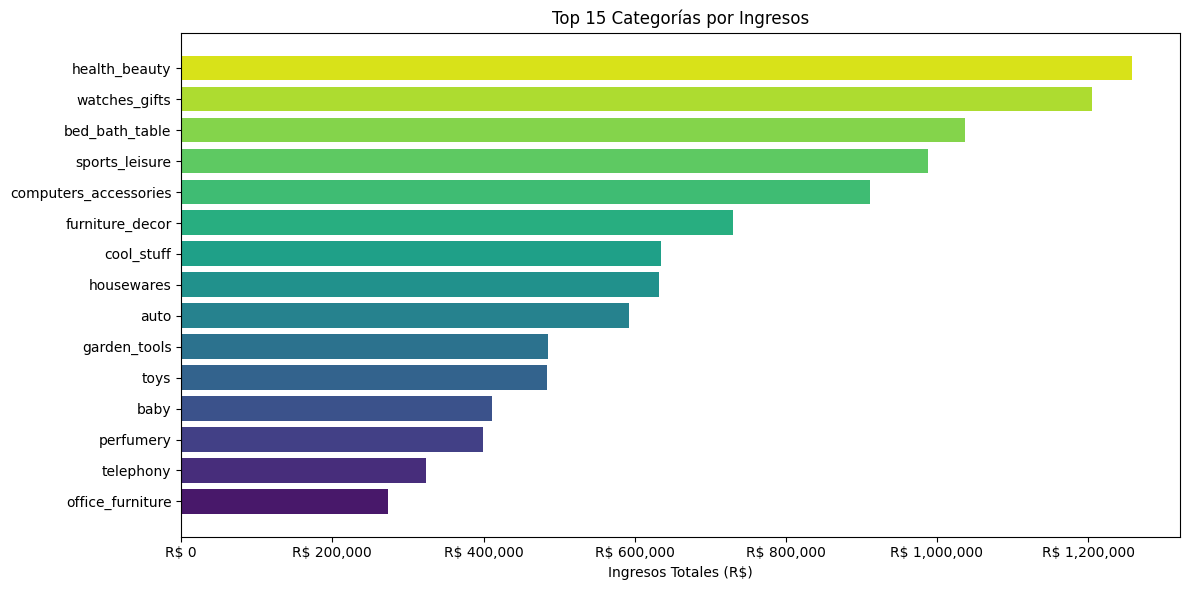

In [ ]:
# Gráfico: Top 15 categorías por ingresos
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(
    pdf_sales_cat["category"][::-1],
    pdf_sales_cat["total_revenue"][::-1],
    color=sns.color_palette("viridis", len(pdf_sales_cat)),
)
ax.set_xlabel("Ingresos Totales (R$)")
ax.set_title("Top 15 Categorías por Ingresos")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
plt.tight_layout()
plt.show()

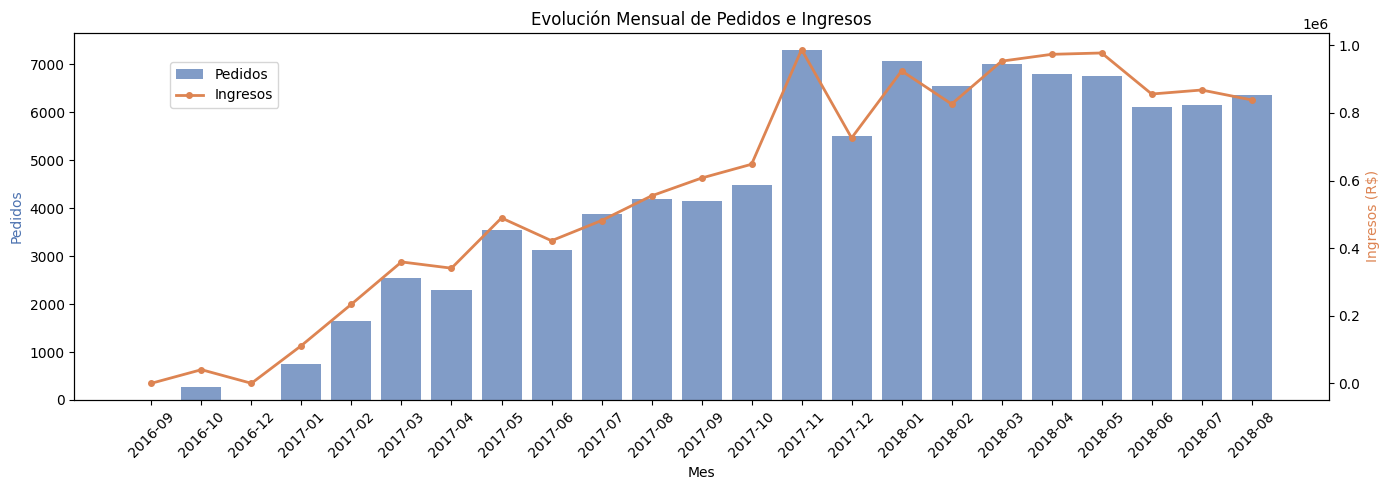

In [ ]:
# Gráfico: Evolución mensual de ventas
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(
    pdf_monthly["month"],
    pdf_monthly["total_orders"],
    color="#4C72B0",
    alpha=0.7,
    label="Pedidos",
)
ax1.set_xlabel("Mes")
ax1.set_ylabel("Pedidos", color="#4C72B0")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    pdf_monthly["month"],
    pdf_monthly["total_revenue"],
    color="#DD8452",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Ingresos",
)
ax2.set_ylabel("Ingresos (R$)", color="#DD8452")

ax1.set_title("Evolución Mensual de Pedidos e Ingresos")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

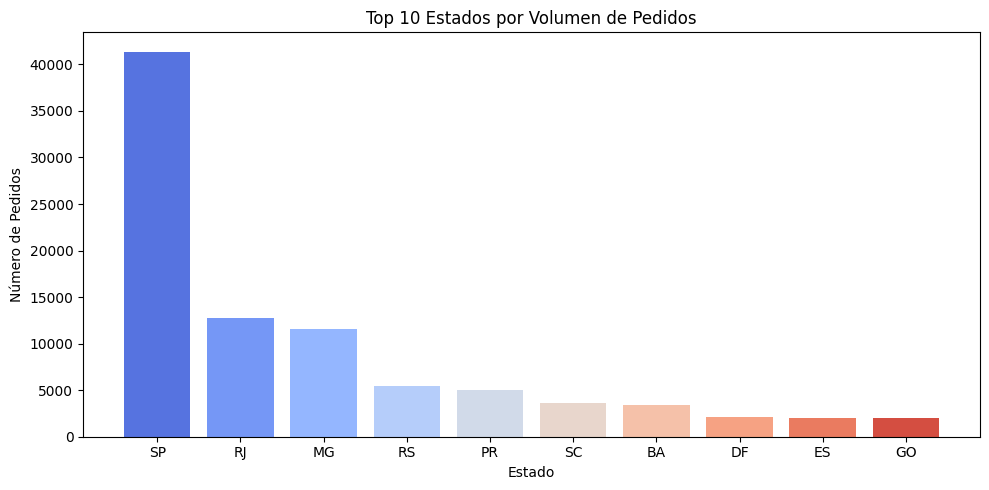

In [ ]:
# Gráfico: Top 10 estados por número de pedidos
pdf_states_top10 = pdf_states.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("coolwarm", len(pdf_states_top10))
ax.bar(pdf_states_top10["state"], pdf_states_top10["total_orders"], color=colors)
ax.set_xlabel("Estado")
ax.set_ylabel("Número de Pedidos")
ax.set_title("Top 10 Estados por Volumen de Pedidos")
plt.tight_layout()
plt.show()

---
### 5. Machine Learning Escalable (Spark MLlib) <a id="lesson5"></a>

En esta sección construimos un pipeline de ML utilizando Spark MLlib:
un modelo supervisado (Regresión Logística) para clasificar la satisfacción
del cliente, y uno no supervisado (K-Means) para segmentación de clientes.

#### 5.1 Preparación de datos

In [ ]:
# Cargar datos desde Parquet
df_ml = spark.read.parquet(PARQUET_PATH)

# Eliminar filas con valores nulos en columnas clave
df_ml = df_ml.dropna(
    subset=[
        "review_score",
        "price",
        "freight_value",
        "payment_value",
        "product_category",
    ]
)

# Asegurar tipo numérico en review_score (puede inferirse como string)
from pyspark.sql.functions import col

df_ml = df_ml.withColumn("review_score", col("review_score").cast("int"))
df_ml = df_ml.dropna(subset=["review_score"])

print(f"Registros disponibles para ML: {df_ml.count()}")
df_ml.show(5)

Registros disponibles para ML: 113233
+--------------------+--------------------+--------------------+--------------+------------+------------------------+--------------------+--------------------+-----+-------------+------------+------------+-------------+
|            order_id|         customer_id|  customer_unique_id|customer_state|order_status|order_purchase_timestamp|          product_id|    product_category|price|freight_value|review_score|payment_type|payment_value|
+--------------------+--------------------+--------------------+--------------+------------+------------------------+--------------------+--------------------+-----+-------------+------------+------------+-------------+
|afa7ff555249234a1...|7daa8a3a2fa25e50b...|7571e21572ea726ef...|            MG|   delivered|     2017-12-05 11:22:23|c4fc1d4489f664ce1...|fashion_bags_acce...| 34.9|         9.09|           5| credit_card|        43.99|
|17279938859725061...|43688fad66340b74b...|500916dd05e1a0eef...|            RJ|   

#### 5.2 Modelo supervisado — Regresión Logística

Clasificaremos los pedidos según la satisfacción del cliente:
- **Satisfecho** (`label = 1`): `review_score >= 4`
- **Insatisfecho** (`label = 0`): `review_score < 4`

In [ ]:
from pyspark.sql.functions import col, when, lit
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
)

# Crear variable objetivo binaria
df_classification = df_ml.withColumn(
    "label", when(col("review_score") >= 4, 1.0).otherwise(0.0)
)

# Distribucion de clases
print("Distribución de la variable objetivo:")
df_classification.groupBy("label").count().show()

Distribución de la variable objetivo:
+-----+-----+
|label|count|
+-----+-----+
|  1.0|86988|
|  0.0|26245|
+-----+-----+



In [ ]:
# Indexar la categoría de producto y tipo de pago
indexer_category = StringIndexer(
    inputCol="product_category", outputCol="category_index", handleInvalid="skip"
)
indexer_payment = StringIndexer(
    inputCol="payment_type", outputCol="payment_index", handleInvalid="skip"
)

# Ensamblar features numéricas
feature_cols = [
    "price",
    "freight_value",
    "payment_value",
    "category_index",
    "payment_index",
]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Modelo de Regresión Logística
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.1,
)

# Pipeline
pipeline_lr = Pipeline(stages=[indexer_category, indexer_payment, assembler, lr])

In [ ]:
# División train/test
train_data, test_data = df_classification.randomSplit([0.8, 0.2], seed=42)
print(f"Datos de entrenamiento: {train_data.count()}")
print(f"Datos de test:          {test_data.count()}")

Datos de entrenamiento: 90760
Datos de test:          22473


In [ ]:
# Entrenar el modelo
model_lr = pipeline_lr.fit(train_data)
predictions_lr = model_lr.transform(test_data)

# Mostrar predicciones
print("Predicciones del modelo de Regresión Logística:")
predictions_lr.select(
    "label", "prediction", "probability", "price", "review_score"
).show(10)

Predicciones del modelo de Regresión Logística:
+-----+----------+--------------------+------+------------+
|label|prediction|         probability| price|review_score|
+-----+----------+--------------------+------+------------+
|  1.0|       1.0|[0.22855059775991...| 59.99|           5|
|  1.0|       1.0|[0.21294544223495...| 109.9|           4|
|  1.0|       1.0|[0.23308812120318...| 135.0|           4|
|  1.0|       1.0|[0.25013865725757...|199.99|           5|
|  1.0|       1.0|[0.22724977244311...| 131.9|           4|
|  0.0|       1.0|[0.24004750966214...|  85.0|           1|
|  0.0|       1.0|[0.23284995045499...|  89.0|           1|
|  0.0|       1.0|[0.21480397755738...|  35.9|           1|
|  0.0|       1.0|[0.23349459221731...|  89.9|           1|
|  1.0|       1.0|[0.22229168533932...| 57.99|           5|
+-----+----------+--------------------+------+------------+
only showing top 10 rows


In [ ]:
# Evaluación del modelo supervisado
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label", metricName="areaUnderROC"
)
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)

auc = evaluator_auc.evaluate(predictions_lr)
accuracy = evaluator_acc.evaluate(predictions_lr)
f1_score = evaluator_f1.evaluate(predictions_lr)

print("Métricas del modelo de Regresión Logística:")
print(f"  AUC-ROC:   {auc:.4f}")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  F1-Score:  {f1_score:.4f}")

Métricas del modelo de Regresión Logística:
  AUC-ROC:   0.5676
  Accuracy:  0.7700
  F1-Score:  0.6705


Predicción,0.0,1.0
Real,,
0.0,10,5167
1.0,2,17294


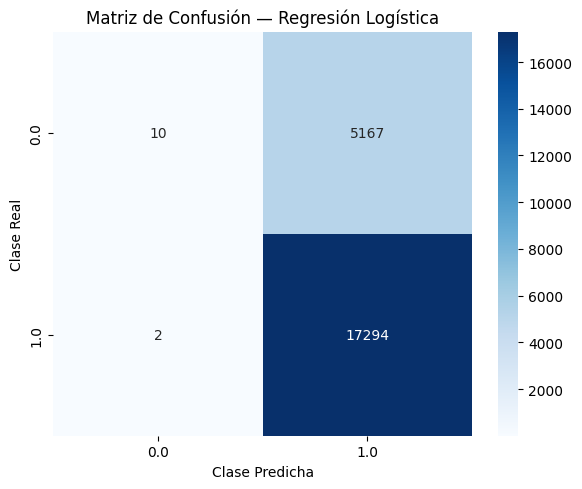

In [ ]:
# Matriz de confusión
pdf_predictions = predictions_lr.select("label", "prediction").toPandas()

confusion = pd.crosstab(
    pdf_predictions["label"],
    pdf_predictions["prediction"],
    rownames=["Real"],
    colnames=["Predicción"],
)
display(confusion)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Matriz de Confusión — Regresión Logística")
ax.set_ylabel("Clase Real")
ax.set_xlabel("Clase Predicha")
plt.tight_layout()
plt.show()

#### 5.3 Modelo no supervisado — K-Means

Segmentaremos a los clientes según su comportamiento de compra:
total gastado, número de pedidos, ticket promedio y calificación media.

In [ ]:
from pyspark.sql.functions import avg, sum as spark_sum, countDistinct
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# Agregar features por cliente
df_customer_features = df_ml.groupBy("customer_unique_id").agg(
    countDistinct("order_id").alias("total_orders"),
    spark_sum("price").alias("total_spent"),
    avg("price").alias("avg_ticket"),
    avg("review_score").alias("avg_review"),
    avg("freight_value").alias("avg_freight"),
)

df_customer_features = df_customer_features.dropna()
print(f"Clientes con features: {df_customer_features.count()}")
df_customer_features.show(5)

Clientes con features: 91500
+--------------------+------------+-----------+----------+----------+-----------+
|  customer_unique_id|total_orders|total_spent|avg_ticket|avg_review|avg_freight|
+--------------------+------------+-----------+----------+----------+-----------+
|24c75405d509b190b...|           1|      89.49|     89.49|       5.0|      15.38|
|b9b4f87b1dda942a4...|           1|     233.98|    116.99|       5.0|      15.57|
|4fd547931d9be10d5...|           1|       50.0|      50.0|       5.0|       9.34|
|2eff60ffbc74b60b6...|           1|     149.99|    149.99|       5.0|      33.31|
|f8ec2178c6a49d0c2...|           1|       24.5|      24.5|       5.0|      11.85|
+--------------------+------------+-----------+----------+----------+-----------+
only showing top 5 rows


In [ ]:
# Ensamblar features para clustering
feature_cols_km = [
    "total_orders",
    "total_spent",
    "avg_ticket",
    "avg_review",
    "avg_freight",
]
assembler_km = VectorAssembler(inputCols=feature_cols_km, outputCol="features")

df_km_input = assembler_km.transform(df_customer_features)

In [ ]:
# Evaluar distintos valores de K usando Silhouette Score
evaluator_sil = ClusteringEvaluator(
    featuresCol="features", metricName="silhouette", distanceMeasure="squaredEuclidean"
)

k_values = range(2, 9)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(featuresCol="features", k=k, seed=42, maxIter=30)
    model_km = kmeans.fit(df_km_input)
    preds = model_km.transform(df_km_input)
    score = evaluator_sil.evaluate(preds)
    silhouette_scores.append(score)
    print(f"  K={k} -> Silhouette = {score:.4f}")

  K=2 -> Silhouette = 0.9582
  K=3 -> Silhouette = 0.8998
  K=4 -> Silhouette = 0.8638
  K=5 -> Silhouette = 0.7938
  K=6 -> Silhouette = 0.7047
  K=7 -> Silhouette = 0.7051
  K=8 -> Silhouette = 0.6829


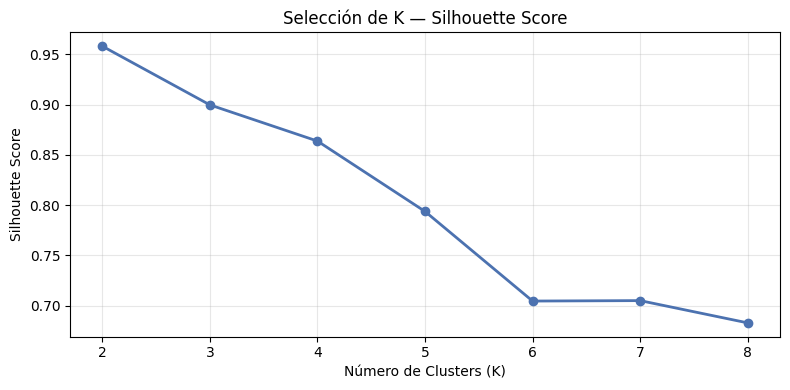

In [ ]:
# Gráfico del codo (Silhouette)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_values), silhouette_scores, marker="o", linewidth=2, color="#4C72B0")
ax.set_xlabel("Número de Clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Selección de K — Silhouette Score")
ax.set_xticks(list(k_values))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Seleccionar el K con mejor Silhouette
best_k = list(k_values)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
print(f"Mejor K: {best_k} (Silhouette = {best_score:.4f})")

Mejor K: 2 (Silhouette = 0.9582)


In [ ]:
# Entrenar modelo final de K-Means
kmeans_final = KMeans(featuresCol="features", k=best_k, seed=42, maxIter=30)
model_km_final = kmeans_final.fit(df_km_input)
df_clustered = model_km_final.transform(df_km_input)

print("Distribución de clusters:")
df_clustered.groupBy("prediction").count().orderBy("prediction").show()

Distribución de clusters:
+----------+-----+
|prediction|count|
+----------+-----+
|         0|89115|
|         1| 2385|
+----------+-----+



In [ ]:
# Perfil de cada cluster
from pyspark.sql.functions import round as spark_round

df_profiles = (
    df_clustered.groupBy("prediction")
    .agg(
        spark_round(avg("total_orders"), 2).alias("avg_orders"),
        spark_round(avg("total_spent"), 2).alias("avg_spent"),
        spark_round(avg("avg_ticket"), 2).alias("avg_ticket"),
        spark_round(avg("avg_review"), 2).alias("avg_review"),
        spark_round(avg("avg_freight"), 2).alias("avg_freight"),
        countDistinct("customer_unique_id").alias("n_customers"),
    )
    .orderBy("prediction")
)

print("Perfiles de clusters:")
df_profiles.show(truncate=False)

Perfiles de clusters:
+----------+----------+---------+----------+----------+-----------+-----------+
|prediction|avg_orders|avg_spent|avg_ticket|avg_review|avg_freight|n_customers|
+----------+----------+---------+----------+----------+-----------+-----------+
|0         |1.03      |120.35   |103.32    |4.16      |19.44      |89115      |
|1         |1.06      |1195.34  |962.62    |4.07      |48.95      |2385       |
+----------+----------+---------+----------+----------+-----------+-----------+



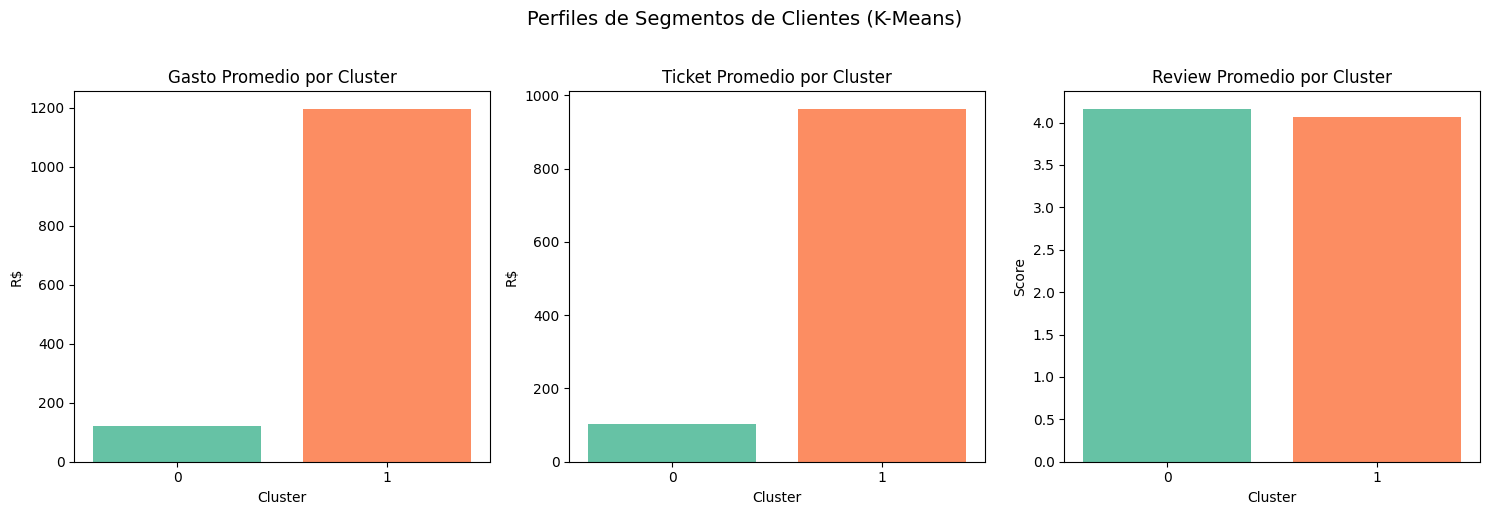

In [ ]:
# Visualización de perfiles
pdf_profiles = df_profiles.toPandas()
pdf_profiles = pdf_profiles.rename(columns={"prediction": "cluster"})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Total gastado promedio
axes[0].bar(
    pdf_profiles["cluster"].astype(str),
    pdf_profiles["avg_spent"],
    color=sns.color_palette("Set2", best_k),
)
axes[0].set_title("Gasto Promedio por Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("R$")

# Ticket promedio
axes[1].bar(
    pdf_profiles["cluster"].astype(str),
    pdf_profiles["avg_ticket"],
    color=sns.color_palette("Set2", best_k),
)
axes[1].set_title("Ticket Promedio por Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("R$")

# Review promedio
axes[2].bar(
    pdf_profiles["cluster"].astype(str),
    pdf_profiles["avg_review"],
    color=sns.color_palette("Set2", best_k),
)
axes[2].set_title("Review Promedio por Cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Score")

plt.suptitle("Perfiles de Segmentos de Clientes (K-Means)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 5.4 Insights para marketing

Los resultados de ambos modelos permiten generar información accionable:

**Regresión Logística (Clasificación de satisfacción):**
- El modelo permite identificar pedidos con alto riesgo de insatisfacción
  basándose en características como el precio, flete y categoría del producto.
- Marketing puede usar estas predicciones para implementar acciones preventivas
  (encuestas post-compra, descuentos compensatorios, seguimiento proactivo).

**K-Means (Segmentación de clientes):**
- Los clusters identificados representan perfiles de compra diferenciados.
- Cada segmento puede recibir estrategias de marketing personalizadas:
  campañas de retención para clientes de alto valor, incentivos de recompra
  para clientes ocasionales, y mejoras de experiencia para segmentos con
  baja calificación promedio.

In [ ]:
# Guardar resultados de segmentación
SEGMENTS_PATH = os.path.join(DATA_DIR, "customer_segments.parquet")
df_clustered.write.mode("overwrite").parquet(SEGMENTS_PATH)
print(f"Segmentos de clientes guardados en: {SEGMENTS_PATH}")

Segmentos de clientes guardados en: data\customer_segments.parquet


In [ ]:
# Cerrar la sesión de Spark
spark.stop()
print("Sesión de Spark cerrada.")

Sesión de Spark cerrada.


## [Reporte Técnico](./technical_report.md)